# Mini Project: Deep Learning with Keras

In this mini-project we'll be building a deep learning classifier using Keras to predict income from the popular [Adult Income dataset](http://www.cs.toronto.edu/~delve/data/adult/adultDetail.html).

Predicting income from demographic and socio-economic information is an important task with real-world applications, such as financial planning, market research, and social policy analysis. The Adult dataset, sometimes referred to as the "Census Income" dataset, contains a vast amount of anonymized data on individuals, including features such as age, education, marital status, occupation, and more. Our objective is to leverage this data to train a deep learning model that can effectively predict whether an individual's income exceeds $50,000 annually or not.

Throughout this Colab, we will walk you through the entire process of building a deep learning classifier using Keras, a high-level neural network API that runs on top of TensorFlow. Keras is known for its user-friendly and intuitive interface, making it an excellent choice for both beginners and experienced deep learning practitioners.

Here's a brief outline of what we will cover in this mini-project:

1. **Data Preprocessing:** We will start by loading and exploring the Adult dataset.

2. **Building the Deep Learning Model:** We will construct a neural network using Keras, where we'll dive into understanding the key components of a neural network, including layers, activation functions, and optimization algorithms.

3. **Model Training:** With our model architecture in place, we will split the data into training and validation sets and train the neural network on the training data. We will monitor the training process to prevent overfitting and enhance generalization.

4. **Model Evaluation:** After training, we'll assess the performance of our model on the test dataset.

By the end of this tutorial, you will not only have a functional deep learning classifier for income prediction but also gain valuable insights into how to leverage the power of neural networks for solving real-world classification tasks.


In [2]:
#!pip install scikeras


[notice] A new release of pip is available: 24.3.1 -> 25.3
[notice] To update, run: pip install --upgrade pip


In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.preprocessing import MinMaxScaler
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from sklearn.metrics import RocCurveDisplay
from keras.models import Sequential
from keras.layers import Dense
from scikeras.wrappers import KerasClassifier
from sklearn.pipeline import Pipeline

You can download the Adult data from the link [here](https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data).

Here are your tasks:

  1. Load the Adult data into a Pandas Dataframe.
  2. Ensure the dataset has properly named columns. If the columns are not read in, assign them by referencing the dataset documentation.
  3. Display the first five rows of the dataset.

In [4]:
DATA_PATH = 'https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data'

# Download the dataset and load it into a pandas DataFrame

# Define column names as they not defined in the CSV file itself (from https://www.cs.toronto.edu/~delve/data/adult/adultDetail.html)
column_names = [
    'age', 'workclass', 'fnlwgt', 'education', 'education-num',
    'marital-status', 'occupation', 'relationship', 'race', 'sex',
    'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'income'
]

# Load the data
df = pd.read_csv(DATA_PATH, skipinitialspace=True, names=column_names, na_values="?")

This took me longer than I would like to admit due to the separator being a comma AND a space. I thought I have worked with python's read_csv before and I thought it defaulted to ignoring leading spaces after the comma but, I guess I've just been dealing with properly minified CSVs.

In [5]:
# Display the first few rows of the DataFrame
print("First 10 rows:")
print(df.head(10))

First 10 rows:
   age         workclass  fnlwgt  education  education-num  \
0   39         State-gov   77516  Bachelors             13   
1   50  Self-emp-not-inc   83311  Bachelors             13   
2   38           Private  215646    HS-grad              9   
3   53           Private  234721       11th              7   
4   28           Private  338409  Bachelors             13   
5   37           Private  284582    Masters             14   
6   49           Private  160187        9th              5   
7   52  Self-emp-not-inc  209642    HS-grad              9   
8   31           Private   45781    Masters             14   
9   42           Private  159449  Bachelors             13   

          marital-status         occupation   relationship   race     sex  \
0          Never-married       Adm-clerical  Not-in-family  White    Male   
1     Married-civ-spouse    Exec-managerial        Husband  White    Male   
2               Divorced  Handlers-cleaners  Not-in-family  White    Ma

If you're not already familiar with the Adult dataset, it's important to do some exploratory data analysis.

Here are your tasks:

  1. Do exploratory data analysis to give you some better intuition for the dataset. This is a bit open-ended. How many rows/columns are there? How are NULL values represented? What's the percentage of positive cases in the dataset?

  2. Drop all rows with NULL values.

  3. Use Scikit-Learn's [LabelEncoder](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.LabelEncoder.html) to convert the `income` column with a data type string to a binary variable.

Dataset shape (rows, columns):
(32561, 15)

Data types:
age                int64
workclass         object
fnlwgt             int64
education         object
education-num      int64
marital-status    object
occupation        object
relationship      object
race              object
sex               object
capital-gain       int64
capital-loss       int64
hours-per-week     int64
native-country    object
income            object
dtype: object
age                  0
workclass         1836
fnlwgt               0
education            0
education-num        0
marital-status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital-gain         0
capital-loss         0
hours-per-week       0
native-country     583
income               0
dtype: int64
age               0.000000
workclass         5.638647
fnlwgt            0.000000
education         0.000000
education-num     0.000000
marital-status    0.000000
occupation        5.660146
relation

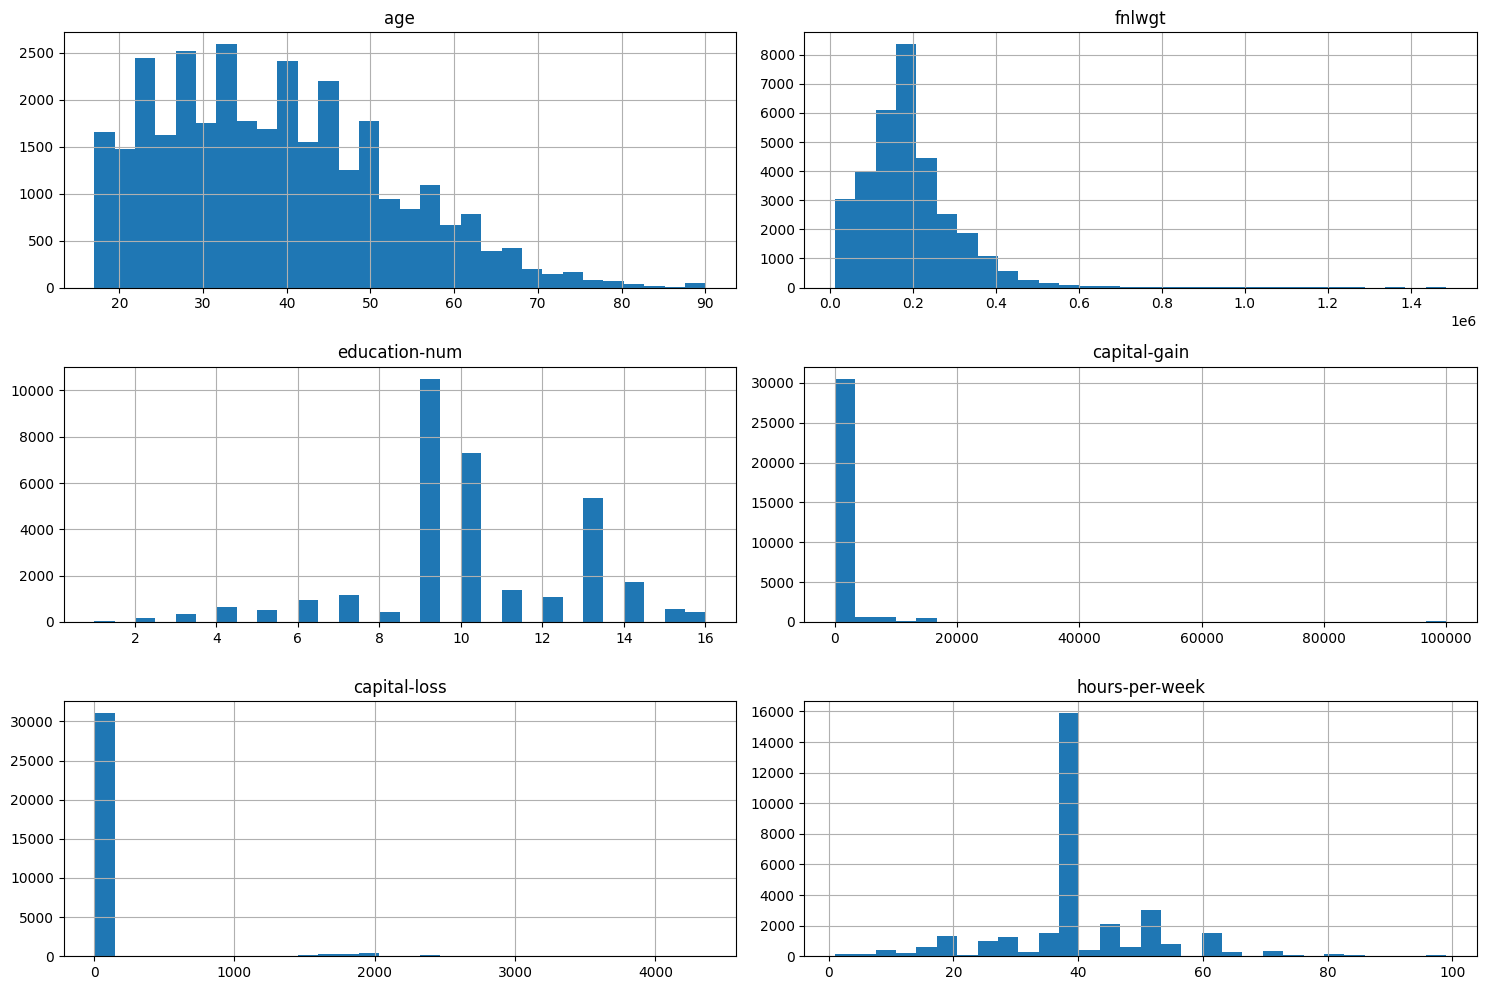

In [6]:
# Do some exploratory analysis.
import matplotlib.pyplot as plt

# How many rows/columns are there?
print(f"Dataset shape (rows, columns):")
print(df.shape)

# What data types are we dealing with here?
print(f"\nData types:")
print(df.dtypes)

# How are NULL values represented??? read_csv pulls in unknown fields as NaN
null_counts = df.isnull().sum()
null_percentages = (df.isnull().sum() / len(df)) * 100
print(null_counts)
print(null_percentages)

# What's the percentrage of positive cases in the dataset?
print("\nTarget (Income) Distribution")
print(df['income'].value_counts())
pcnt = (df['income'].value_counts(normalize=True) * 100)
print("\nby Percentage:")
print(pcnt)

print(f"\nDuplicate rows:")
print(df.duplicated().sum())

numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
df[numerical_cols].hist(figsize=(15, 10), bins=30)
plt.tight_layout()
plt.show()


* 14 features and 1 target (15 cols)
* Data is a mix of continuous and categorical
* Data is fairly heavily weighted on the <=50k target value.
  * I found this normalize trick rahter handy: value_counts(normalize=True), but it prints a little weird
* 24 duplicate rows - could be a real data though!
* Histograms
  * Age is more heavily represented under ~45, which feels odd
  * I had to google for what fnlwgt even was as the description page was not helpful. I think we should drop this, as it's metadata about the census sampling.
  * Education looks fairly normal distribution
  * capital gains/loss - not a great spread and therefor probably not a great feature to include
  * Hours oer week seems like a nice normal distribution and a good prediction feature.

In [7]:
# Find all NULL values and drop them
df = df.dropna().copy()
print(df.isnull().sum())

age               0
workclass         0
fnlwgt            0
education         0
education-num     0
marital-status    0
occupation        0
relationship      0
race              0
sex               0
capital-gain      0
capital-loss      0
hours-per-week    0
native-country    0
income            0
dtype: int64


**Poof, no more null Values, that's cool.**

In [8]:
# Use Scikit-Learn's LabelEncoder to convert the income column with a data type
# string to a binary variable.

# from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()

# Fit and transform the income column
# Since we are replacing the column in df, this cell cannot be rerun in isolation
df['income'] = label_encoder.fit_transform(df['income'])
print(df['income'].value_counts())

# Get the mapping from binary to the label
print("\nLabel mapping:")
print(label_encoder.classes_)

income
0    22654
1     7508
Name: count, dtype: int64

Label mapping:
['<=50K' '>50K']


**So <=50K is at index 0, so 0 is what we have transformed that to. >50K == 1**

1. Split the data into training and test sets. Remember not to include the label you're trying to predict, `income`, as a column in your training data.

In [9]:
# Split dataset into training and test sets
# Separate features (X) and target (y)
X = df.drop('income', axis=1)
y = df['income']

# Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      # 20% test
    random_state=42,    # Hitchhikers Guide represent! I like that the ML community has rallied around this #
    stratify=y          # #BEcause the target/income is skewed heavily to 0 (<=50K)
)

In machine learning, the Receiver Operating Characteristic (ROC) curve and the Area Under the Curve (AUC) metric are commonly used to evaluate the performance of binary classification models. These are valuable tools for understanding how well a model can distinguish between the positive and negative classes in a classification problem.

Let's break down each concept:

1. ROC Curve:
The ROC curve is a graphical representation of a binary classifier's performance as the discrimination threshold is varied. It is created by plotting the True Positive Rate (TPR) against the False Positive Rate (FPR) at different threshold values. Here's how these rates are calculated:

- True Positive Rate (TPR), also called Sensitivity or Recall, measures the proportion of actual positive instances that are correctly identified by the model:
   TPR = True Positives / (True Positives + False Negatives)

- False Positive Rate (FPR) measures the proportion of actual negative instances that are incorrectly classified as positive by the model:
   FPR = False Positives / (False Positives + True Negatives)

The ROC curve is useful because it shows how well a classifier can trade off between sensitivity and specificity across different threshold values. The ideal ROC curve hugs the top-left corner, indicating a high TPR and low FPR, meaning the classifier is excellent at distinguishing between the two classes.

2. AUC (Area Under the Curve):
The AUC is a scalar metric derived from the ROC curve. It represents the area under the ROC curve, hence its name. The AUC ranges from 0 to 1, where 0 indicates a very poor classifier (always predicting the opposite class) and 1 signifies a perfect classifier (making all correct predictions).

The AUC metric is beneficial because it provides a single value to summarize the classifier's overall performance across all possible threshold values. It is particularly useful when dealing with imbalanced datasets, where one class significantly outnumbers the other. In such cases, accuracy alone might not be a reliable evaluation metric, and AUC can provide a more robust performance measure.

A quick rule of thumb for interpreting AUC values:
- AUC ≈ 0.5: The model performs no better than random guessing.
- 0.5 < AUC < 0.7: The model has poor to fair performance.
- 0.7 < AUC < 0.9: The model has good to excellent performance.
- AUC ≈ 1: The model is close to or has a perfect performance.

Here are your tasks:

  1. Use Scikit-Learn's [roc_auc_score](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.roc_auc_score.html) to calculate the AUC score for a method that always predicts the majority class.  

In [10]:
# Use Scikit-Learn's roc_auc_score to calculate the AUC score for a method that
# always predicts the majority class.

# We already know the majority class is 0, or "<=50K" from previous work above. Could do this programatically but.... why bother?

# Create predictions that always predict the majority class
y_pred_majority_class = np.full(shape=y_test.shape, fill_value=0) #0 is the majority class

# Calculate AUC score
auc_majority_class = roc_auc_score(y_test, y_pred_majority_class)
print(f"\nAUC Score: {auc_majority_class:.4f}")


AUC Score: 0.5000


Given the above
* AUC ≈ 0.5: The model performs no better than random guessing.

We made a good dummy /baseline classifier. We could also have used DummyClassifier here.

Now, let's do a little feature engineering.

1. Use Scikit-Learn's [ColumnTransformer](https://scikit-learn.org/stable/modules/generated/sklearn.compose.ColumnTransformer.html) to apply One Hot Encoding to the categorical variables in `workclass`, `education`, `marital-status`, `occupation`, `relationship`, 'race', `sex`, and `native-country`. Also, apply [MinMaxScaler](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.MinMaxScaler.html) to the remaining continuous features. How many columns will the dataframe have after these columns transformations are applied?

In [11]:
# Use Scikit-Learn's ColumnTransformer to apply One Hot Encoding to the
# categorical variables in workclass, education, marital-status, occupation,
# relationship, 'race', sex, and native-country. #Also, apply MinMaxScaler to
# the remaining continuous features.

# Gotta call out categorical and numerical columns first
categorical_cols = ['workclass', 'education', 'marital-status', 'occupation',
                   'relationship', 'race', 'sex', 'native-country']

numerical_cols = ['age', 'fnlwgt', 'education-num', 'capital-gain',
                 'capital-loss', 'hours-per-week']

# Create the two transformations
preprocessor = ColumnTransformer(
    transformers=[
        ('num', MinMaxScaler(), numerical_cols),
        ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), categorical_cols)
    ],
    remainder='drop'  # Or 'passthrough'?? Not sure if it matters here since I define all the columns
)

# Fit and transform the training AND test data
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)



In [18]:
# How many columns will the dataframe have after these columns transformations are applied?
# Check the shapes
print(f"Original training shape:")
print(X_train.shape)
print(f"Processed training shape: ")
print(X_train_processed.shape)

Original training shape:
(24129, 14)
Processed training shape: 
(24129, 96)
[[0.10958904 0.12839382 0.8        ... 1.         0.         0.        ]
 [0.5890411  0.07356975 0.6        ... 1.         0.         0.        ]
 [0.08219178 0.07526223 0.8        ... 1.         0.         0.        ]
 ...
 [0.42465753 0.09842432 0.53333333 ... 1.         0.         0.        ]
 [0.5890411  0.15447475 0.2        ... 1.         0.         0.        ]
 [0.4109589  0.14536862 0.53333333 ... 1.         0.         0.        ]]


**So, much bigger, which is expected with so many One Hot Encodings and each of those having multiple values**

Unforunately, this is a numpy.ndarray, so we no longer have column names to peek at, and I am curious.

In [19]:
column_names_transformed = preprocessor.get_feature_names_out()
print(column_names_transformed)

['num__age' 'num__fnlwgt' 'num__education-num' 'num__capital-gain'
 'num__capital-loss' 'num__hours-per-week' 'cat__workclass_Local-gov'
 'cat__workclass_Private' 'cat__workclass_Self-emp-inc'
 'cat__workclass_Self-emp-not-inc' 'cat__workclass_State-gov'
 'cat__workclass_Without-pay' 'cat__education_11th' 'cat__education_12th'
 'cat__education_1st-4th' 'cat__education_5th-6th'
 'cat__education_7th-8th' 'cat__education_9th' 'cat__education_Assoc-acdm'
 'cat__education_Assoc-voc' 'cat__education_Bachelors'
 'cat__education_Doctorate' 'cat__education_HS-grad'
 'cat__education_Masters' 'cat__education_Preschool'
 'cat__education_Prof-school' 'cat__education_Some-college'
 'cat__marital-status_Married-AF-spouse'
 'cat__marital-status_Married-civ-spouse'
 'cat__marital-status_Married-spouse-absent'
 'cat__marital-status_Never-married' 'cat__marital-status_Separated'
 'cat__marital-status_Widowed' 'cat__occupation_Armed-Forces'
 'cat__occupation_Craft-repair' 'cat__occupation_Exec-managerial'

Unsuprisingly, country really took a lot of columns.

Keras is an open-source deep learning library written in Python. It was developed to provide a user-friendly, high-level interface for building and training neural networks. The library was created by François Chollet and was first released in March 2015 as part of the Deeplearning4j project. Later, it became part of the TensorFlow ecosystem and is now the official high-level API for TensorFlow.

Keras is designed to be modular, user-friendly, and easy to extend. It allows researchers and developers to quickly prototype and experiment with various deep learning models. One of the primary goals of Keras is to enable fast experimentation, making it simple to build and iterate on different architectures.

Key features of Keras include:

1. User-friendly API: Keras provides a simple and intuitive interface for defining and training deep learning models. Its design philosophy focuses on ease of use and clarity of code.

2. Modularity: Models in Keras are built as a sequence of layers, and users can easily stack, merge, or create complex architectures using a wide range of predefined layers.

3. Extensibility: Keras allows users to define custom layers, loss functions, and metrics. This flexibility enables researchers to experiment with new ideas and algorithms seamlessly.

4. Backends: Initially, Keras supported multiple backends, including TensorFlow, Theano, and CNTK. However, as of TensorFlow version 2.0, TensorFlow has become the primary backend for Keras.

5. Multi-GPU and distributed training: Keras supports training models on multiple GPUs and in distributed computing environments, making it suitable for large-scale experiments.

6. Pre-trained models: Keras includes a collection of pre-trained models for common tasks, such as image classification (e.g., VGG, ResNet, MobileNet) and natural language processing (e.g., Word2Vec, GloVe).

The integration of Keras into TensorFlow as its official high-level API has solidified its position as one of the most popular deep learning libraries in the machine learning community. Its ease of use and versatility have contributed to its widespread adoption in both academia and industry for a wide range of deep learning tasks.

Here are your tasks:

1. Create your own model in Keras to predict income in the Adult training data. Remember, it's always better to start simple and add complexity to the model if necessary. What's a good loss function to use?

2. Keras can be integrated with Scitkit-Learn using a wrapper. Use the [KerasClassifier wrapper](https://adriangb.com/scikeras/stable/generated/scikeras.wrappers.KerasClassifier.html) to integrate your Keras model with the ColumnTransformer from previous steps using a [Pipeline](https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.Pipeline.html) object.

3. Fit your model.

4. Calculate the AUC score of your model on the test data. Does the model predict better than random?

5. Generate an ROC curve for your model using [RocCurveDisplay](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.RocCurveDisplay.html). What would the curve look like if all your predictions were randomly generated? What would the curve look like if it you had a perfect model?

In [22]:
# Define the Keras model
# Don't forget, this needs to be made as a function, to pass it into the Classifier

def create_model():
    keras_model = Sequential()

    # Add our input layer and first layer (dense)
    keras_model.add(Dense(64, activation='relu', input_dim=X_train_processed.shape[1]))

    # Add a second hidden (dense)
    keras_model.add(Dense(32, activation='relu'))

    # Output layer (binary classification)
    keras_model.add(Dense(1, activation='sigmoid'))

    # Compile the model
    keras_model.compile(
        optimizer='adam', #Using adam as this was what we learned, but it looks like we have more options
        loss='binary_crossentropy', #Using because our output is a binary classification
        metrics=['accuracy']
    )

    return keras_model

**I had to go back a bit in my notes to get this all going. Also my notes were poor, since this was DataCamp stuff (my fault.) But really, this is like the second lesson, of 9 - I almost wish we'd had this assignment sooner in the lineup. I might look at the next assignment as I take future lessons and work along**

In [23]:
# Create a Keras classifier
keras_classifier = KerasClassifier(
    model=create_model,
    epochs=50, #Lessons suggested 20-100. Try 50.
    batch_size=32, #Lessons said powers of two, and 16 seemed too small.
    verbose=1
)

In [24]:
# Create the scikit-learn pipeline
keras_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', keras_classifier)
])

In [25]:
# Fit the pipeline on the training data
# Is this going to burn up my computer?
keras_pipeline.fit(X_train, y_train)

Epoch 1/50


/Users/jsg/repos/sbml/.venv/lib/python3.13/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


755/755 ━━━━━━━━━━━━━━━━━━━━ 1s 577us/step - accuracy: 0.8190 - loss: 0.3806
Epoch 2/50
755/755 ━━━━━━━━━━━━━━━━━━━━ 0s 558us/step - accuracy: 0.8403 - loss: 0.3402
Epoch 3/50
755/755 ━━━━━━━━━━━━━━━━━━━━ 0s 571us/step - accuracy: 0.8455 - loss: 0.3289
Epoch 4/50
755/755 ━━━━━━━━━━━━━━━━━━━━ 0s 576us/step - accuracy: 0.8479 - loss: 0.3227
Epoch 5/50
755/755 ━━━━━━━━━━━━━━━━━━━━ 1s 664us/step - accuracy: 0.8515 - loss: 0.3175
Epoch 6/50
755/755 ━━━━━━━━━━━━━━━━━━━━ 0s 609us/step - accuracy: 0.8520 - loss: 0.3138
Epoch 7/50
755/755 ━━━━━━━━━━━━━━━━━━━━ 0s 557us/step - accuracy: 0.8557 - loss: 0.3098
Epoch 8/50
755/755 ━━━━━━━━━━━━━━━━━━━━ 0s 558us/step - accuracy: 0.8566 - loss: 0.3077
Epoch 9/50
755/755 ━━━━━━━━━━━━━━━━━━━━ 0s 561us/step - accuracy: 0.8598 - loss: 0.3035
Epoch 10/50
755/755 ━━━━━━━━━━━━━━━━━━━━ 0s 549us/step - accuracy: 0.8607 - loss: 0.3011
Epoch 11/50
755/755 ━━━━━━━━━━━━━━━━━━━━ 0s 550us/step - accuracy: 0.8621 - loss: 0.2977
Epoch 12/50
755/755 ━━━━━━━━━━━━━━━━━━━━ 

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


**Actually, cool output while training each epoch.**
Accuracy seems not great compared to previous ML models but I do get the impression that NN are tricker. Much better than the baseline/dummy but not great.

In [47]:
# Calculate the AUC score of your model on the test data.
# Does the model predict better than random?
#keras_predictions = keras_pipeline.predict(X_test)
keras_predictions = keras_pipeline.predict_proba(X_test)[:, 1]

auc_majority_class = roc_auc_score(y_test, keras_predictions)
print(f"AUC Score: {auc_majority_class:}")

189/189 ━━━━━━━━━━━━━━━━━━━━ 0s 355us/step
AUC Score: 0.8881947589339425


Man I didn't have this in my notes at all - looked back and the DataCamp exercises never did AUC for these models in code I don't think.
Anyway, I used predict first, and I got a crazy looking ROC curve chart below. Read the [roc_auc_score document](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.roc_auc_score.html#sklearn.metrics.roc_auc_score) slower/better and figured out I needed to use predict_proba(). I did not catch that the first time looking at docs because I didn't use RandomClassifier, like I probably should have, and didn't learn about predict_proba at that time.
Oh well.

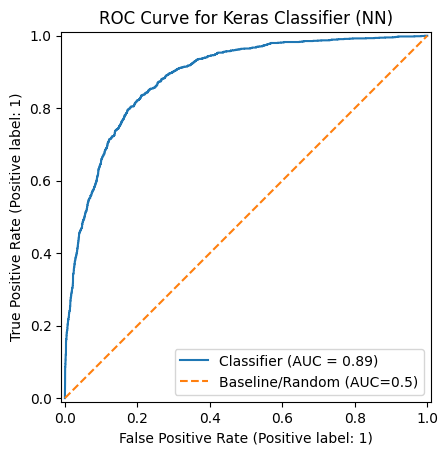

In [59]:
# Generate an ROC curve for your model.
RocCurveDisplay.from_predictions(y_test, keras_predictions)

#add the baseline prediction - this syntax is weird. I woudl expect coordinate points.
plt.plot([0, 1], [0, 1], '--', label='Baseline/Random (AUC=0.5)')
plt.title('ROC Curve for Keras Classifier (NN)')
plt.legend() #Needed this for some reason to show both roc and my added plot

Q: What would the curve look like if all your predictions were randomly generated?
- A: A diagonal line from 0,0 to 1,1. I was able to add the baseline to the chart itself

Q: What would the curve look like if it you had a perfect model?
- I think it would be A vertical line up the y axis, and a horizontal one across the X axis at the top. Like [this](https://classeval.wordpress.com/wp-content/uploads/2015/06/a-roc-curve-of-a-perfect-classifier.png?w=560)